<img src="../assets/sendfast-logo-dark-text.png" alt="SendFast" width="260">

# SendFast Q1 2024 Analysis

SendFast is a remittance startup that offers fast, affordable cross-border payments at competitive exchange rates. Its main corridors are Canada ↔ Nigeria. *(SendFast and its data are fictional.)*

**Question:** How healthy is SendFast's business, and where should leadership focus next?

**Data:** `data/transactions.csv` (164,882 transfers, 31 Dec 2023 – 31 Mar 2024) and
`data/users.csv` (21,906 users who signed up 1 Dec 2023 – 31 Mar 2024).

## Executive summary

1. **Customers stay.** About 12,300 people send money every month, and 79% of each month's senders send again the next month.
2. **Each transfer is worth less.** Transfer counts and senders are flat, but monthly value fell 14% (CA\$21.9M in January to CA\$18.8M in March). The average CAD→NGN transfer dropped from CA\$236 to CA\$205 while the naira weakened from about 980 per CAD in January to 1,100–1,160 in February–March.
3. **NGN→CAD is the high-value business.** It is 13.5% of remittances but 48% of remittance value, with an average of CA\$1,300 per transfer. 40% of these transfers are school-related.
4. **New signups rarely become senders.** Of users who had at least 30 days to convert, 6.4% transacted. The biggest leak is KYC: 60% of those signups never started it (70% in Nigeria).
5. **Referral gets Nigerian signups through KYC.** Compared within country, referred signups are 5.6× as likely to send in Nigeria (10.7% vs 1.9%) and 1.7× in Canada (27.1% vs 15.5%). The lift happens at KYC: 76% of referred Nigerians start it, against 28.5% of others. After the first transfer, referred and other senders keep sending at the same rate.

**Scope note:** the users table is a slice covering *new signups* from Dec–Mar, while the transactions table covers *all* customers who sent money.
Only 1,187 of the 16,444 people who transacted appear in the users table. Funnel and referral results therefore describe new signups, not the whole customer base (Section 2).

## 1. Setup and cleaning

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option('display.width', 160)
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10})
# SendFast brand colours, sampled from the logo
BLUE, ORANGE, GREY = '#434c54', '#e66227', '#a3a9b3'   # BLUE = brand slate, kept as the variable name

DATA = '../data/'
df_transactions = pd.read_csv(DATA + 'transactions.csv')
df_users = pd.read_csv(DATA + 'users.csv')
print(df_transactions.shape, df_users.shape)

(164882, 10) (21906, 14)


In [2]:
# Transactions: consistent snake_case names (spelling 'receive' correctly)
df_transactions = df_transactions.rename(columns={
    'Id': 'id', 'DateCreated': 'date', 'UserId': 'user_id', 'SendAmount': 'send_amount',
    'SendCurrencyId': 'send_currency', 'ReceiveAmount': 'receive_amount',
    'ReceiveCurrencyId': 'receive_currency', 'Narration': 'narration',
    'ExchangeRate': 'rate', 'BaseAmount': 'base_amount_cad'})
df_transactions['date'] = pd.to_datetime(df_transactions['date']).dt.strftime('%Y-%m-%d')
df_transactions['corridor'] = df_transactions['send_currency'] + '→' + df_transactions['receive_currency']
# Same-currency 'transfers' are account/wallet debits, not remittances (see Section 2)
df_transactions['is_remittance'] = df_transactions['send_currency'] != df_transactions['receive_currency']

# Users: this export is already snake_case apart from one column
df_users = df_users.rename(columns={'Is_deactivated': 'is_deactivated'})
df_users['country'] = df_users['country'].str.title()
df_users['region'] = df_users['region'].str.title().fillna('Unknown')
df_users['occupation'] = df_users['occupation'].fillna('Undisclosed')
# KYC code-to-label mapping (code 5 does not occur; source of mapping unconfirmed)
df_users['kyc_status'] = df_users['kyc_status'].replace(
    {1: 'NOT_STARTED', 2: 'PENDING', 3: 'PASSED', 4: 'IN_REVIEW', 6: 'FAILED'})
df_users['dob'] = pd.to_datetime(df_users['dob'].replace('#NAME?', pd.NA).str.split(' ').str[0], errors='coerce')

print('Duplicate transaction ids:', df_transactions['id'].duplicated().sum())
print('Duplicate user ids:', df_users['user_id'].duplicated().sum())
print('Transactions with no user_id:', df_transactions['user_id'].isna().sum())

Duplicate transaction ids: 0
Duplicate user ids: 0
Transactions with no user_id: 61


## 2. Data quality checks
These checks change how the results should be read, so they come before the analysis.

In [3]:
txn_users = set(df_transactions['user_id'].dropna())
signup_users = set(df_users['user_id'])
matched = txn_users & signup_users
m_rows = df_transactions['user_id'].isin(signup_users)
print(f'People who transacted: {len(txn_users):,}')
print(f'...of whom appear in the users table: {len(matched):,} ({len(matched)/len(txn_users):.1%})')
print(f'Share of transfers / value from matched users: {m_rows.mean():.1%} / '
      f'{df_transactions.loc[m_rows, "base_amount_cad"].sum() / df_transactions["base_amount_cad"].sum():.1%}')

# Does the users table cover every sender, or only new signups?
first_txn = (df_transactions[m_rows].groupby('user_id')['date'].min().rename('first_txn')
             .reset_index().merge(df_users[['user_id', 'signup_date']], on='user_id'))
days = (pd.to_datetime(first_txn['first_txn']) - pd.to_datetime(first_txn['signup_date'])).dt.days
print(f'Matched users whose first transfer is before signup: {(days < 0).sum()}  (median days to first transfer: {days.median():.0f})')
unm = df_transactions[~m_rows & df_transactions['user_id'].notna() & (df_transactions['date'] >= '2024-01-01')]
always = (unm.groupby('user_id')['date'].apply(lambda d: d.str[:7].nunique()) == 3).sum()
print(f'Unmatched users active in all of Jan, Feb and Mar: {always:,}')

People who transacted: 16,444
...of whom appear in the users table: 1,187 (7.2%)
Share of transfers / value from matched users: 4.1% / 5.8%
Matched users whose first transfer is before signup: 0  (median days to first transfer: 15)
Unmatched users active in all of Jan, Feb and Mar: 7,985


**Reading:** IDs share one format, no matched user transacted before signing up, and 7,985 unmatched users transacted in every month.
So the users table holds **new signups (Dec–Mar)** and the transactions table holds the **whole customer base**, most of whom signed up earlier.
This means:
- Base health, corridor and retention results (Sections 3–6) cover all customers.
- Funnel and referral results (Sections 7–8) cover new signups only.
- "First seen" in January is not the same as "new customer", because the data starts on 31 Dec. This analysis therefore does not split customers into new and returning.

In [4]:
dq = {
    'December data is partial (only 31 Dec present)': df_transactions['date'].str[:7].eq('2023-12').sum(),
    'Transfers with base amount of 0': (df_transactions['base_amount_cad'] <= 0).sum(),
    'Same-currency debits (NGN→NGN, CAD→CAD)': (~df_transactions['is_remittance']).sum(),
    'Users with placeholder DOB 2001-01-01': (df_users['dob'] == '2001-01-01').sum(),
    'Users aged over 100 at 31 Mar 2024': ((pd.Timestamp('2024-03-31') - df_users['dob']).dt.days / 365.25 > 100).sum(),
    'kyc_verified=True but status not PASSED': (df_users['kyc_verified'] & (df_users['kyc_status'] != 'PASSED')).sum(),
}
display(pd.Series(dq, name='rows').to_frame())

print(df_transactions.loc[~df_transactions['is_remittance']].groupby('corridor')['narration']
      .agg(lambda s: s.value_counts(normalize=True).head(1).round(3).to_dict()))
print(pd.crosstab(df_users['dob'] == '2001-01-01', df_users['gender']))

,rows
December data is partial (only 31 Dec present),1733
Transfers with base amount of 0,301
"Same-currency debits (NGN→NGN, CAD→CAD)",2796
Users with placeholder DOB 2001-01-01,4162
Users aged over 100 at 31 Mar 2024,4
kyc_verified=True but status not PASSED,17


corridor
CAD→CAD    {'Debit Account': 0.878}
NGN→NGN    {'Debit Account': 0.985}
Name: narration, dtype: object
gender  Female   Male  Non-Binary
dob                              
False     4850  12827          67
True         1     17        4144


**Reading:**
- Same-currency rows are almost all "Debit Account", so they are left out of corridor analysis.
- The 2001-01-01 date of birth almost always comes with gender = Non-Binary (4,144 of 4,211). A simple count would show 19% of users as Non-Binary, but this is a **form default, not real data**, so gender and age are not used in this analysis.
- December is excluded from all growth rates. Including it would show a misleading +3,089% month-on-month jump.

In [5]:
conn = sqlite3.connect(':memory:')
df_users.assign(dob=df_users['dob'].dt.strftime('%Y-%m-%d')).to_sql('users', conn, index=False)
df_transactions.to_sql('transactions', conn, index=False)
conn.execute('CREATE INDEX ix_txn_user ON transactions(user_id)')
sql = lambda q: pd.read_sql_query(q, conn)

## 3. Base health: flat senders, falling value
Full months only (Jan–Mar 2024). Active users are counted as **distinct** senders, not transactions.

In [6]:
monthly = sql('''
SELECT STRFTIME('%Y-%m', date)            AS month,
       COUNT(DISTINCT user_id)            AS active_senders,
       COUNT(id)                          AS transfers,
       SUM(base_amount_cad)               AS value_cad,
       ROUND(AVG(base_amount_cad), 0)     AS avg_transfer_cad
FROM transactions
WHERE date >= '2024-01-01' AND user_id IS NOT NULL
GROUP BY 1 ORDER BY 1
''')
for c in ['active_senders', 'transfers', 'value_cad']:
    monthly[c + '_mom_%'] = (monthly[c].pct_change() * 100).round(1)
display(monthly)
jan, mar = monthly.iloc[0], monthly.iloc[-1]
print(f"Jan→Mar: senders {mar.active_senders/jan.active_senders-1:+.1%}, transfers {mar.transfers/jan.transfers-1:+.1%}, "
      f"value {mar.value_cad/jan.value_cad-1:+.1%}")

,month,active_senders,transfers,value_cad,avg_transfer_cad,active_senders_mom_%,transfers_mom_%,value_cad_mom_%
0,2024-01,12405,55226,21918451,397.0,NaN,NaN,NaN
1,2024-02,12285,53140,19267577,363.0,-1.0,-3.8,-12.1
2,2024-03,12246,54723,18792554,343.0,-0.3,3.0,-2.5


Jan→Mar: senders -1.3%, transfers -0.9%, value -14.3%


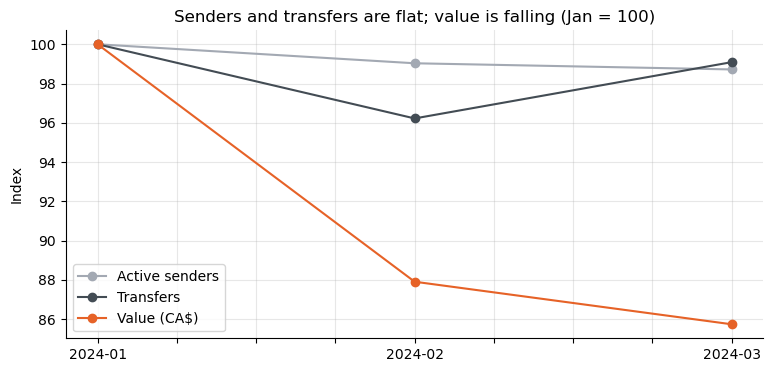

In [7]:
fig, ax = plt.subplots()
idx = monthly.set_index('month')[['active_senders', 'transfers', 'value_cad']]
(idx / idx.iloc[0] * 100).plot(ax=ax, marker='o', color=[GREY, BLUE, ORANGE])
ax.set_title('Senders and transfers are flat; value is falling (Jan = 100)')
ax.set_ylabel('Index'); ax.set_xlabel(''); ax.legend(['Active senders', 'Transfers', 'Value (CA$)'])
plt.show()

## 4. Retention
A sender is retained if they transact in the month (or week) straight after one where they transacted.

In [8]:
ret_m = sql('''
WITH act AS (SELECT DISTINCT user_id, STRFTIME('%Y-%m', date) m FROM transactions
             WHERE user_id IS NOT NULL AND date >= '2024-01-01')
SELECT a.m AS from_month, COUNT(a.user_id) AS senders,
       COUNT(b.user_id) AS retained,
       ROUND(COUNT(b.user_id) * 100.0 / COUNT(a.user_id), 1) AS retention_pct
FROM act a
LEFT JOIN act b ON a.user_id = b.user_id AND b.m = STRFTIME('%Y-%m', DATE(a.m || '-01', '+1 month'))
WHERE a.m < '2024-03'
GROUP BY 1
''')
display(ret_m)

# Weeks start Monday; only full weeks 1 Jan – 31 Mar
ret_w = sql('''
WITH act AS (SELECT DISTINCT user_id, DATE(date, 'weekday 0', '-6 days') w FROM transactions
             WHERE user_id IS NOT NULL AND date >= '2024-01-01')
SELECT a.w AS week, COUNT(a.user_id) AS senders, COUNT(b.user_id) AS retained,
       ROUND(COUNT(b.user_id) * 100.0 / COUNT(a.user_id), 1) AS retention_pct
FROM act a LEFT JOIN act b ON a.user_id = b.user_id AND b.w = DATE(a.w, '+7 days')
WHERE a.w < (SELECT MAX(w) FROM act)
GROUP BY 1 ORDER BY 1
''')
print(f"Average week-to-week retention: {ret_w['retention_pct'].mean():.1f}%")

,from_month,senders,retained,retention_pct
0,2024-01,12405,9743,78.5
1,2024-02,12285,9695,78.9


Average week-to-week retention: 55.3%


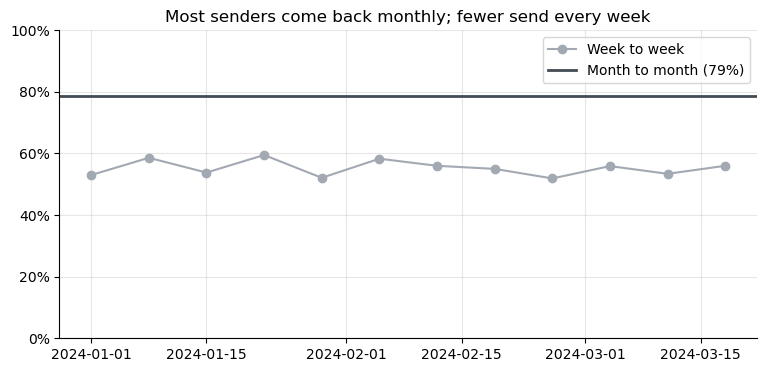

In [9]:
fig, ax = plt.subplots()
ax.plot(pd.to_datetime(ret_w['week']), ret_w['retention_pct'], marker='o', color=GREY, label='Week to week')
ax.axhline(ret_m['retention_pct'].mean(), color=BLUE, lw=2, label=f"Month to month ({ret_m['retention_pct'].mean():.0f}%)")
ax.set_ylim(0, 100); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Most senders come back monthly; fewer send every week'); ax.legend(); plt.show()

**Reading:** Monthly retention is about 79% in both full-month transitions. Weekly retention is lower (about 55%), which is expected because many remittances are sent monthly. The customer base is stable.

## 5. Why value is falling: smaller transfers as the naira weakens

In [10]:
ticket = sql('''
SELECT STRFTIME('%Y-%m', date) AS month, corridor,
       ROUND(AVG(base_amount_cad), 0) AS avg_transfer_cad,
       COUNT(DISTINCT user_id)        AS senders,
       COUNT(id)                      AS transfers,
       ROUND(AVG(CASE WHEN corridor = 'CAD→NGN' THEN rate END), 0) AS avg_ngn_per_cad
FROM transactions
WHERE date >= '2024-01-01' AND corridor IN ('CAD→NGN', 'NGN→CAD')
GROUP BY 1, 2 ORDER BY 2, 1
''')
display(ticket)

,month,corridor,avg_transfer_cad,senders,transfers,avg_ngn_per_cad
0,2024-01,CAD→NGN,236.0,10227,46422,977.0
1,2024-02,CAD→NGN,210.0,10213,44860,1157.0
2,2024-03,CAD→NGN,205.0,10054,46190,1101.0
3,2024-01,NGN→CAD,1358.0,2752,7603,NaN
4,2024-02,NGN→CAD,1303.0,2671,7102,NaN
5,2024-03,NGN→CAD,1240.0,2643,7012,NaN


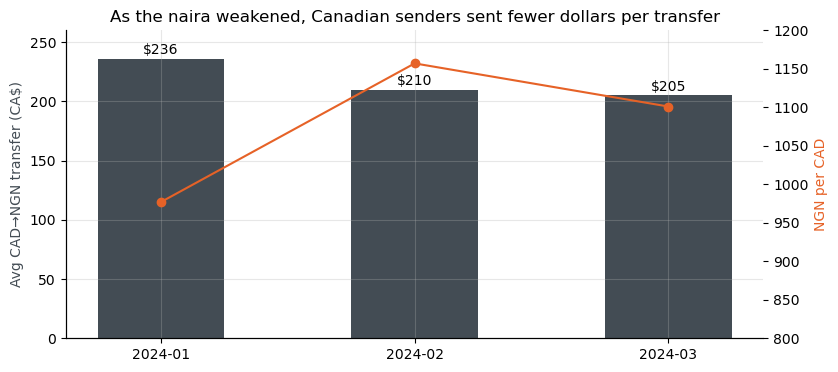

In [11]:
cad = ticket[ticket['corridor'] == 'CAD→NGN'].set_index('month')
fig, ax = plt.subplots()
ax.bar(cad.index, cad['avg_transfer_cad'], color=BLUE, width=0.5)
ax.set_ylabel('Avg CAD→NGN transfer (CA$)', color=BLUE); ax.set_ylim(0, 260)
for x, y in zip(cad.index, cad['avg_transfer_cad']):
    ax.text(x, y + 4, f'${y:.0f}', ha='center')
ax2 = ax.twinx(); ax2.plot(cad.index, cad['avg_ngn_per_cad'], color=ORANGE, marker='o'); ax2.grid(False)
ax2.set_ylabel('NGN per CAD', color=ORANGE); ax2.set_ylim(800, 1200)
ax.set_title('As the naira weakened, Canadian senders sent fewer dollars per transfer')
plt.show()

**Reading:** In both main corridors, sender counts and transfer counts are steady, but average transfer size fell: CAD→NGN by 13% and NGN→CAD by 9%.
The likely cause is that, with each CAD buying more naira, senders need fewer dollars to cover the same obligations at home.
This is correlation over three months, not proof, but it means **CAD value is exposed to the NGN rate**, not only to customer behaviour.

## 6. Corridors and customers
Remittances only (same-currency debits excluded).

In [12]:
corr = sql('''
SELECT corridor,
       COUNT(id)                                   AS transfers,
       COUNT(DISTINCT user_id)                     AS senders,
       SUM(base_amount_cad)                        AS value_cad,
       ROUND(AVG(base_amount_cad), 0)              AS avg_transfer_cad
FROM transactions WHERE is_remittance = 1
GROUP BY 1 ORDER BY value_cad DESC
''')
corr['transfer_share_%'] = (corr['transfers'] / corr['transfers'].sum() * 100).round(1)
corr['value_share_%'] = (corr['value_cad'] / corr['value_cad'].sum() * 100).round(1)
display(corr)

purpose = sql('''
SELECT corridor, narration, COUNT(*) AS n FROM transactions
WHERE corridor IN ('CAD→NGN', 'NGN→CAD') GROUP BY 1, 2
''')
purpose['share_%'] = (purpose['n'] / purpose.groupby('corridor')['n'].transform('sum') * 100).round(1)
display(purpose.sort_values(['corridor', 'n'], ascending=[True, False]).groupby('corridor').head(4))

,corridor,transfers,senders,value_cad,avg_transfer_cad,transfer_share_%,value_share_%
0,CAD→NGN,138929,13255,30077598,216.0,85.7,50.9
1,NGN→CAD,21956,4599,28536556,1300.0,13.5,48.2
2,CAD→USD,145,93,175907,1213.0,0.1,0.3
3,CAD→GHS,630,127,173403,275.0,0.4,0.3
4,CAD→KES,198,52,55259,279.0,0.1,0.1
5,NGN→USD,20,6,41903,2095.0,0.0,0.1
6,CAD→AUD,33,25,40095,1215.0,0.0,0.1
7,NGN→GHS,140,40,35972,257.0,0.1,0.1
8,NGN→KES,8,7,5853,732.0,0.0,0.0
9,CAD→EUR,12,6,3357,280.0,0.0,0.0


,corridor,narration,n,share_%
55,CAD→NGN,Other Personal Services,33804,24.3
35,CAD→NGN,Grants and Gifts,30403,21.9
31,CAD→NGN,Goods and Services,22189,16.0
71,CAD→NGN,School-Related,18682,13.4
226,NGN→CAD,School-Related,8837,40.2
220,NGN→CAD,Other Personal Services,5393,24.6
205,NGN→CAD,Goods and Services,2319,10.6
209,NGN→CAD,Grants and Gifts,1509,6.9


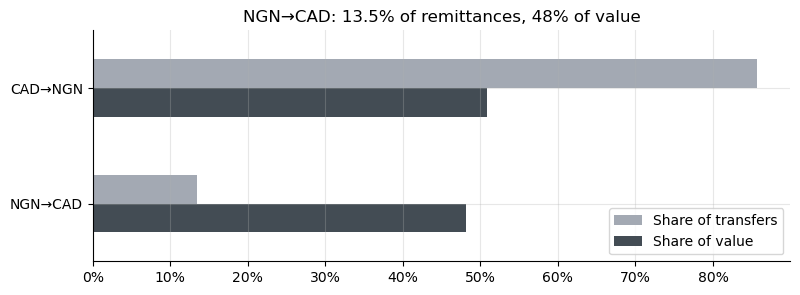

In [13]:
top = corr.head(2).set_index('corridor')[['transfer_share_%', 'value_share_%']]
ax = top.plot.barh(color=[GREY, BLUE], figsize=(9, 3))
ax.xaxis.set_major_formatter(mtick.PercentFormatter()); ax.set_ylabel('')
ax.set_title('NGN→CAD: 13.5% of remittances, 48% of value'); ax.legend(['Share of transfers', 'Share of value'])
ax.invert_yaxis(); plt.show()

In [14]:
# How concentrated is value across customers?
uv = sql('SELECT user_id, SUM(base_amount_cad) v FROM transactions WHERE user_id IS NOT NULL GROUP BY 1 ORDER BY v DESC')
n = len(uv)
print(f'Top 1% of customers ({n//100:,}) = {uv.v.head(n//100).sum()/uv.v.sum():.0%} of value; '
      f'top 10% ({n//10:,}) = {uv.v.head(n//10).sum()/uv.v.sum():.0%}')

Top 1% of customers (164) = 12% of value; top 10% (1,644) = 51%


## 7. New signups: the funnel
Cohort: users who signed up **1 Dec 2023 – 29 Feb 2024**, so everyone had at least 30 days to transact before the data ends. March signups are shown separately as immature.

In [15]:
funnel = sql('''
WITH s AS (
  SELECT u.*, (SELECT 1 FROM transactions t WHERE t.user_id = u.user_id LIMIT 1) IS NOT NULL AS transacted
  FROM users u WHERE signup_date < '2024-03-01')
SELECT 1 stage, 'Signed up' AS step, COUNT(*) users FROM s
UNION ALL SELECT 2, 'Completed profile', SUM(completed_profile) FROM s
UNION ALL SELECT 3, 'Started KYC', SUM(kyc_status <> 'NOT_STARTED') FROM s
UNION ALL SELECT 4, 'KYC passed', SUM(kyc_status = 'PASSED') FROM s
UNION ALL SELECT 5, 'Transacted', SUM(transacted) FROM s
ORDER BY stage
''')
funnel['% of signups'] = (funnel['users'] / funnel['users'].iloc[0] * 100).round(1)
funnel['% of previous step'] = (funnel['users'] / funnel['users'].shift() * 100).round(1)
display(funnel)

,stage,step,users,% of signups,% of previous step
0,1,Signed up,16333,100.0,NaN
1,2,Completed profile,9806,60.0,60.0
2,3,Started KYC,6533,40.0,66.6
3,4,KYC passed,3477,21.3,53.2
4,5,Transacted,1046,6.4,30.1


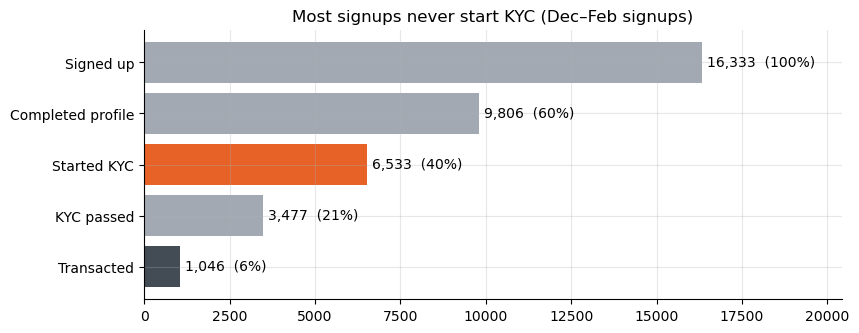

In [16]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(funnel['step'], funnel['users'], color=[GREY, GREY, ORANGE, GREY, BLUE])
for y, (v, p) in enumerate(zip(funnel['users'], funnel['% of signups'])):
    ax.text(v + 150, y, f'{v:,}  ({p:.0f}%)', va='center')
ax.invert_yaxis(); ax.set_xlim(0, funnel['users'].max() * 1.25)
ax.set_title('Most signups never start KYC (Dec–Feb signups)'); plt.show()

In [17]:
# Signup-to-first-transfer rate and KYC progress by country (Dec–Feb cohort)
by_country = sql('''
WITH s AS (
  SELECT u.*, EXISTS (SELECT 1 FROM transactions t WHERE t.user_id = u.user_id) AS transacted
  FROM users u WHERE signup_date < '2024-03-01' AND country IN ('Canada', 'Nigeria'))
SELECT country, COUNT(*) AS signups,
       ROUND(AVG(kyc_status = 'NOT_STARTED') * 100, 1) AS never_started_kyc_pct,
       ROUND(AVG(kyc_status = 'PASSED') * 100, 1)      AS kyc_passed_pct,
       ROUND(AVG(transacted) * 100, 1)                 AS conversion_pct
FROM s GROUP BY 1
''')
display(by_country)

,country,signups,never_started_kyc_pct,kyc_passed_pct,conversion_pct
0,Canada,4627,34.1,42.2,17.3
1,Nigeria,11670,70.3,13.0,2.1


**Reading:**
- The largest drop comes before KYC even starts. Passing KYC isn't enough on its own either: only about 3 in 10 KYC-passed users go on to send.
- Nigeria is where the leak is: 70% of Nigerian signups never start KYC (against 34% in Canada), and only 2.1% ever send. Nigerians are 71% of signups.
- 12 users transacted without passing KYC. That's a small number, but compliance should look at it.

## 8. Referral: the lever that gets signups through KYC
Referred signups are about 71% Canadian, against about 23% of other signups, and Canadians convert better anyway.
Comparing all referred signups with all others (22.3% vs 5.3%) therefore overstates the effect, so referral is compared **within each country**.

In [18]:
ref = sql('''
WITH s AS (
  SELECT u.*, EXISTS (SELECT 1 FROM transactions t WHERE t.user_id = u.user_id) AS transacted
  FROM users u WHERE signup_date < '2024-03-01' AND country IN ('Canada', 'Nigeria'))
SELECT country,
       CASE WHEN referred_by IS NOT NULL THEN 'Referred' ELSE 'Not referred' END AS grp,
       COUNT(*)                                        AS signups,
       ROUND(AVG(kyc_status <> 'NOT_STARTED') * 100, 1) AS started_kyc_pct,
       ROUND(AVG(kyc_status = 'PASSED') * 100, 1)       AS kyc_passed_pct,
       ROUND(AVG(transacted) * 100, 1)                 AS conversion_pct
FROM s GROUP BY 1, 2 ORDER BY 1, 2
''')
display(ref)
p = ref.pivot(index='country', columns='grp', values='conversion_pct')
print((p['Referred'] / p['Not referred']).round(1).rename('Conversion lift from referral (x)').to_string())

,country,grp,signups,started_kyc_pct,kyc_passed_pct,conversion_pct
0,Canada,Not referred,3884,62.7,39.1,15.5
1,Canada,Referred,743,82.6,58.3,27.1
2,Nigeria,Not referred,11363,28.5,11.9,1.9
3,Nigeria,Referred,307,75.9,56.0,10.7


country
Canada     1.7
Nigeria    5.6


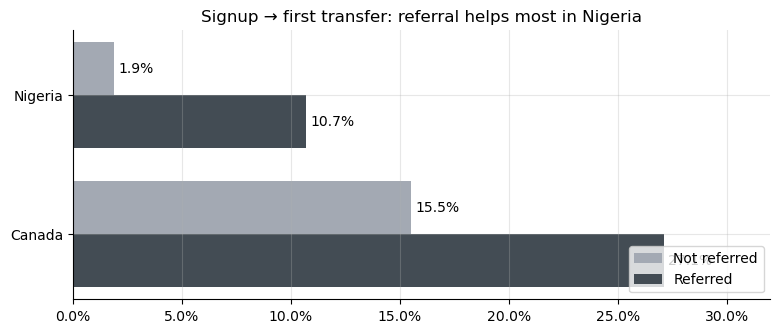

In [19]:
fig, ax = plt.subplots(figsize=(9, 3.5))
countries = ['Nigeria', 'Canada']; y = range(len(countries)); h = 0.38
for i, (grp, col) in enumerate([('Not referred', GREY), ('Referred', BLUE)]):
    bars = ax.barh([v + (i - 0.5) * h for v in y], p.loc[countries, grp], h, color=col, label=grp)
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_yticks(list(y), countries); ax.invert_yaxis(); ax.set_xlim(0, 32)
ax.xaxis.set_major_formatter(mtick.PercentFormatter()); ax.legend(loc='lower right')
ax.set_title('Signup → first transfer: referral helps most in Nigeria'); plt.show()

In [20]:
# Does referral also make new senders stay? Same window for everyone:
# repeat = another transfer within 30 days of the first (first transfer on or before 1 Mar);
# still sending = a transfer on days 31–60 (first transfer on or before 31 Jan).
tx = df_transactions.dropna(subset=['user_id']).assign(date=lambda d: pd.to_datetime(d['date']))
first = tx.groupby('user_id')['date'].min().rename('first_txn')
new = df_users[['user_id', 'referred_by']].merge(first, left_on='user_id', right_index=True)
new = new[new['first_txn'] <= '2024-03-01'].copy()
new['grp'] = new['referred_by'].notna().map({True: 'Referred', False: 'Not referred'})
days = tx.merge(new[['user_id', 'first_txn']], on='user_id')
days['day'] = (days['date'] - days['first_txn']).dt.days
new['repeat_30d'] = new['user_id'].isin(days.loc[days['day'].between(1, 30), 'user_id'])
new['active_31_60d'] = new['user_id'].isin(days.loc[days['day'].between(31, 60), 'user_id'])
eligible = new['first_txn'] <= '2024-01-31'
retention = pd.DataFrame({
    'new senders': new.groupby('grp').size(),
    'sent again within 30 days %': (new.groupby('grp')['repeat_30d'].mean() * 100).round(1),
    'still sending on days 31–60 %': (new[eligible].groupby('grp')['active_31_60d'].mean() * 100).round(1),
})
display(retention)

share = sql('''
SELECT STRFTIME('%Y-%m', signup_date) AS signup_month, COUNT(*) AS signups,
       ROUND(AVG(referred_by IS NOT NULL) * 100, 1) AS referred_share_pct
FROM users GROUP BY 1 ORDER BY 1
''')
display(share)

,new senders,sent again within 30 days %,still sending on days 31–60 %
grp,,,
Not referred,677,70.3,58.7
Referred,200,72.5,58.3


,signup_month,signups,referred_share_pct
0,2023-12,7417,6.4
1,2024-01,5175,6.1
2,2024-02,3741,7.0
3,2024-03,5573,3.8


**Reading:**
- Within country, referred signups are **5.6× as likely to send in Nigeria** (10.7% vs 1.9%) and 1.7× in Canada (27.1% vs 15.5%).
- The lift happens at KYC. 76% of referred Nigerians start KYC and 56% pass it, against 28.5% and 12% of other Nigerians.
- Referral doesn't change what happens after the first transfer: about 7 in 10 send again within 30 days in both groups, and about 58% are still sending on days 31–60.
- Referral is therefore an activation lever, not a retention lever.
- The referral share of signups fell to 3.8% in March, from 6–7% before. That needs checking before the programme is scaled.
- **Caveats:** there are only 307 referred Nigerians in the cohort, and referred people may already be more motivated. A test would confirm whether referral causes the lift.

## 9. Recommendations

| # | Action | Evidence | Measure of success |
|---|---|---|---|
| 1 | **Get Nigerian signups into KYC.** Start KYC straight after signup, show the required documents up front, and follow up with people who stall at days 1, 3 and 7. | 70% of Nigerian signups never start KYC; they convert at 2.1% | Share of Nigerian signups starting KYC within 14 days (28.5% ever start today) |
| 2 | **Use referrals to drive KYC.** Ask loyal Canadian senders to invite the people they send to; pay the reward once the invitee passes KYC and makes a first transfer. First check why referrals fell to 3.8% of signups in March. | Within country, referred Nigerians start KYC at 76% vs 28.5% and send 5.6× as often | Referred signups per month, and the share who pass KYC and send |
| 3 | **Protect NGN→CAD tuition payments.** Run targeted lifecycle campaigns for school-related senders (marketing to design the details), and look after the top senders. | 48% of remittance value, 40% school-related; top 10% of customers = 51% of value | NGN→CAD value retention; top-customer churn |